# **Post-Treatement of the simulaiton for the Tsanfleuron glacier**
The aim of this notebook is to import the different simulations of the Tsanfleuron glacier and calculate the volumes returns by the different methods.

## **Input :**
* MPS simulation set run with considering the ti as hard conditionning data
* MPS simulation set run without considering the ti as hard conditionning data
* GRF simulation
* Kriging estimation

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import pickle
import os
import time
from matplotlib.backends.backend_pdf import PdfPages
import georasters as gr


## Import the simulations

In [44]:
path_output_krig = '../simulation_output_krig/'
path_output_MPS  = '../simulation_output/'

simulation_name_krig = os.listdir(path_output_krig)
simulation_name      = os.listdir(path_output_MPS)

exec(open('../functions/03_indice_calculation_functions.py').read())

In [47]:
simulation_name, simulation_name_krig

(['realisation1_simu.pickle'], ['realisation1_krige.pickle'])

In [53]:
with open(path_output_MPS+simulation_name[0],'rb') as file:
        real_alt, simu_sets, mask, referential= pickle.load(file)
with open(path_output_krig+simulation_name_krig[0],'rb') as file:
        real_alt, krig, mask, referential= pickle.load(file)

## Import the DEM

In [41]:
file_path_DEM = '../data/DEM/pickle/DEM_glacier_cut.pickle'

if os.path.isfile(file_path_DEM):
    print('Le fichier est présent. import')
    with open(file_path_DEM,'rb')as file:
        data_DEM_Glacier = pickle.load(file)

else:
    print('error')

Le fichier est présent. import


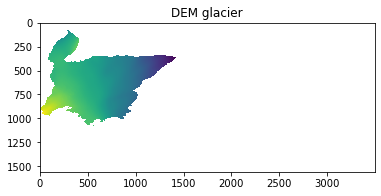

In [43]:
plt.imshow(data_DEM_Glacier)
plt.title('DEM glacier')
plt.show()

## We extract the glaier zone for the different simulation sets

In [34]:
def extract(simu, mask):
    simuOut = np.full((simu.shape[0],simu.shape[1]),np.nan)
    simu[mask!=1] = np.nan
    return simu

In [126]:
def recut(simu):
    simu_cut = np.full((1200,1500),np.nan)
    simu_cut = simu[:1200,:1500]
    return simu_cut                       

In [134]:
set_name  = ['MPS', 'MPS2', 'GRF']
simus_cut = {}

for i in range(len(simu_sets)):
    simus_cut[set_name[i]] = []
    for simu in simu_sets[i]:
        simus_cut[set_name[i]].append(recut(extract(simu, mask)))
        
simus_cut['Krig']=[]
simus_cut['Krig'].append(recut(extract(krig[0],mask)))

mask = recut(mask)
data_DEM_Glacier = recut(data_DEM_Glacier)

In [69]:
simus_cut.keys()

dict_keys(['MPS', 'MPS2', 'GRF', 'Krig'])

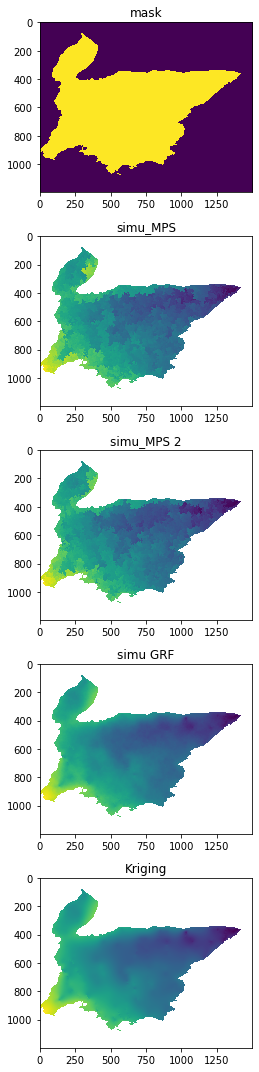

In [135]:
plt.subplots(5,1,figsize=(15,15))
plt.subplot(5,1,1)
plt.imshow(mask)
plt.title('mask')
plt.subplot(5,1,2)
plt.imshow(simus_cut['MPS'][0])
plt.title('simu_MPS')
plt.subplot(5,1,3)
plt.imshow(simus_cut['MPS2'][0])
plt.title('simu_MPS 2')
plt.subplot(5,1,4)
plt.imshow(simus_cut['GRF'][0])
plt.title('simu GRF')
plt.subplot(5,1,5)
plt.imshow(simus_cut['Krig'][0])
plt.title('Kriging')
plt.tight_layout()
plt.show()

## We calcule the different volumes

In [169]:
volumes   = {}
diff_mean = {}
for key in simus_cut.keys():
    volumes[key]=[]
    diff_list = []
    for simu in simus_cut[key]:
        diff = data_DEM_Glacier-simu
        diff_list.append(diff)
        diff[diff<0] = np.nan  #to remove the diff inf to zero
        volumes[key].append(np.nansum(diff)*4)
        
    diff_mean[key]=[np.mean(diff_list,axis=0)]

In [113]:
for key in volumes.keys():
    print('Mean volumen for the {} set is : {}m3 '.format(str(key),str(np.mean(volumes[key]))))

Mean volumen for the MPS set is : 151919838.10375908m3 
Mean volumen for the MPS2 set is : 152871257.806731m3 
Mean volumen for the GRF set is : 153820030.3609097m3 
Mean volumen for the Krig set is : 153784311.84003633m3 


In [115]:
for key in volumes.keys():
    print('Mean volumen for the {} set is : {}m3 '.format(str(key),str(np.mean(volumes[key]))))

Mean volumen for the MPS set is : 153954952.52055603m3 
Mean volumen for the MPS2 set is : 155016577.30866614m3 
Mean volumen for the GRF set is : 153987501.42373008m3 
Mean volumen for the Krig set is : 153895841.9867338m3 


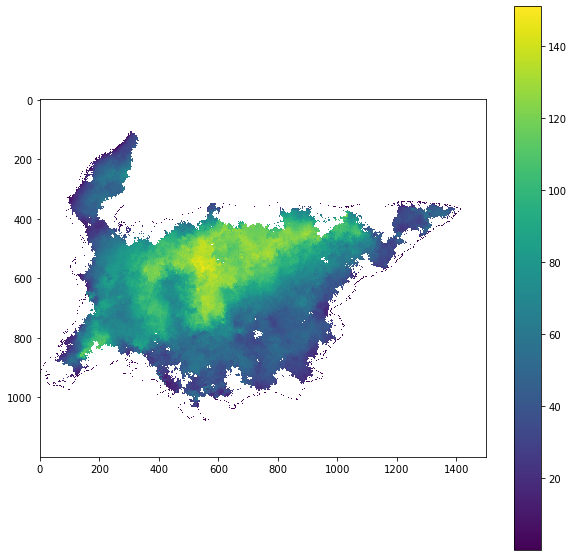

In [167]:
plt.figure(figsize=(10,10))
plt.imshow(diff_mean['MPS'][0],vmin=np.nanmin(diff_mean['MPS'][0]))
plt.colorbar()
plt.show()

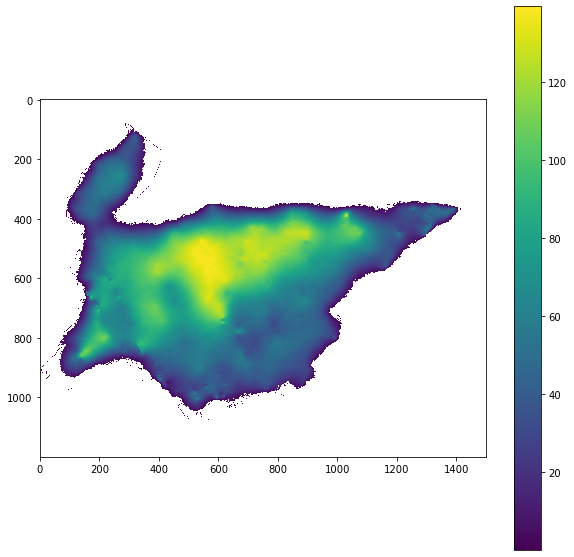

In [168]:
plt.figure(figsize=(10,10))
plt.imshow(diff_mean['GRF'][0],vmin=np.nanmin(diff_mean['GRF'][0]))
plt.colorbar()
plt.show()

## Apres cette ligne on peut tout virer?

In [7]:
all_output = []
real_vol = []
type_sim = ['MPS1','MPS2','GRF','KRIG']
for name, name_krig in zip(simulation_name,simulation_name_krig):
    it = 0
    with open(path_output_MPS+name,'rb') as file:
        real_alt, simus_sets, mask, referential= pickle.load(file)
    
    with open(path_output_krig+name_krig,'rb') as file:
         real_k, krieg_sets, mask, referential = pickle.load(file)

    for simus in simus_sets:        
        pro = indice_calculation(np.zeros(simus[0].shape),simus,'mps')
        
        all_output.append([name,type_sim[it]] + pro)
        it = it + 1
        
        
    #pro = indice_calculation(np.zeros(simus[0].shape),krieg_sets,'krig')
    all_output.append([name,type_sim[it]] + [0,0,0,krieg_sets[0],krieg_sets[1], 0])
results_frame = pd.DataFrame(data =all_output, columns=['Sim_name','Type','Error','Abs_error','Norm_Error','Mean','Sd','Volume'])



In [6]:
mask.shape

NameError: name 'mask' is not defined

In [173]:
simus_sets[0][0].shape

(1556, 3492)

In [8]:
ref
ref_DEM = [np.int(np.around((data_DEM_Glacier.geot[0]-referential[0])/2,decimals=0)),np.int(np.around((data_DEM_Glacier.geot[3]-referential[1])/-2,decimals=0))]

if ref_DEM[0]<0:
    glacier_to_add = data_DEM_Glacier.raster[:,-ref_DEM[0]:]
    ref_DEM[0] = 0
elif ref_DEM[1]<0:
    glacier_to_add = data_DEM_Glacier.raster[np.int(-ref_DEM[1]):,:]
    ref_DEM[1] = 0

full_dem = np.zeros(mask.shape)
full_dem[ref_DEM[1]:glacier_to_add.shape[0]+ref_DEM[1], ref_DEM[0]:glacier_to_add.shape[1]+ref_DEM[0]] = glacier_to_add

NameError: name 'ref' is not defined

In [13]:

full_dem = np.zeros(mask.shape)
full_dem[ref_DEM[1]:glacier_to_add.shape[0]+ref_DEM[1], ref_DEM[0]:glacier_to_add.shape[1]+ref_DEM[0]] = glacier_to_add
mask = mask == 1
full_dem[~mask] = np.nan


NameError: name 'glacier_to_add' is not defined

In [10]:
plt.imshow(full_dem)
plt.imshow(results_frame[results_frame['Type']=='MPS2'].Mean[1])

NameError: name 'full_dem' is not defined

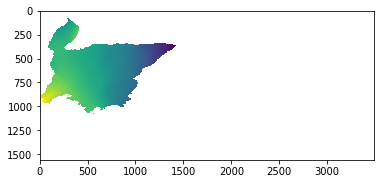

In [168]:
plt.imshow(full_dem)


In [11]:
for name, name_krig in zip(simulation_name,simulation_name_krig):

    with open(path_output_MPS+name,'rb') as file:
        real_alt, simus_sets, mask, referential= pickle.load(file)
    
    with open(path_output_krig+name_krig,'rb') as file:
         real_k, krieg_sets, mask, referential = pickle.load(file)

    for simus in simus_sets:        
        vol = []
        for sub in simus:
            vol.append(np.nansum(full_dem[:-1,:-1] - sub)*2)
        

NameError: name 'full_dem' is not defined

In [172]:
vol

[76982256.26497532, 76594386.20815669]

In [ ]:
#np.shape(real_alt)
#real_alt.shape
simus_sets
results_frame

In [36]:
data_DEM_Glacier.geot[0]

582170.0

In [37]:
referential

[582190.2921, 131224.0]

In [18]:
results_frame

,Sim_name,Type,Error,Abs_error,Norm_Error,Mean,Sd,Volume
0,realisation1_simu.pickle,MPS1,NaN,NaN,NaN,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[nan, nan]"
1,realisation1_simu.pickle,MPS2,NaN,NaN,NaN,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[nan, nan]"
2,realisation1_simu.pickle,GRF,1193.214343,1197.524464,3.275254e+11,"[[2001.4379336846064, 2003.3587890053068, 2004...","[[4.945621931932919, 4.412856135215293, 4.0547...","[-6225349884.530368, -6225213819.493546]"
3,realisation1_simu.pickle,KRIG,0.000000,0.000000,0.000000e+00,"[[2020.7123835216667, 2022.6201273288234, 2024...",None,0


In [15]:
dirName ='simu_reports'
numbers = []
try:
    # Create target Directory
    os.mkdir(dirName)
    print("Directory " , dirName ,  " Created ") 
    pdf_name = 'pdf_report_001.pdf'
except FileExistsError:
    print("Directory " , dirName ,  " already exists")
    pdf_name = os.listdir(dirName)
    for pdf_me in pdf_name:
        numbers.append(pdf_me[11:12])
    pdf_name = 'pdf_report_'+ str(int(max(numbers))+1).rjust(3, '0')+'.pdf' 


Directory  simu_reports  already exists


In [16]:
pdf_name

'pdf_report_010.pdf'

Text(0, 0.5, 'Error [m]')

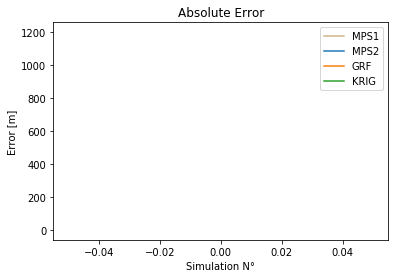

In [6]:
plt.plot(results_frame[results_frame['Type']=='MPS1'].Abs_error.values,color='tan')
plt.plot(results_frame[results_frame['Type']=='MPS2'].Abs_error.values)
plt.plot(results_frame[results_frame['Type']=='GRF'].Abs_error.values)
plt.plot(results_frame[results_frame['Type']=='KRIG'].Abs_error.values)
plt.legend(['MPS1','MPS2','GRF','KRIG'])
plt.title('Absolute Error')
plt.xlabel('Simulation N°')
plt.ylabel('Error [m]')
#plt.plot(np.ones(len(pts_0))*2,color='grey',ls='--')


In [ ]:
plt.plot(results_frame[results_frame['Type']=='MPS1'].Error.values,color='tan')
plt.plot(results_frame[results_frame['Type']=='MPS2'].Error.values)
plt.plot(results_frame[results_frame['Type']=='GRF'].Error.values)
plt.plot(results_frame[results_frame['Type']=='KRIG'].Error.values)
plt.legend(['MPS1','MPS2','GRF','KRIG'])
plt.title('Error')
plt.xlabel('Simulation N°')
plt.ylabel('Error [m]')

#plt.plot(np.ones(len(pts_0))*0,color='grey',ls='--')

In [ ]:
plt.plot(results_frame[results_frame['Type']=='MPS1'].Norm_Error.values,color='tan')
plt.plot(results_frame[results_frame['Type']=='MPS2'].Norm_Error.values)
plt.plot(results_frame[results_frame['Type']=='GRF'].Norm_Error.values)
plt.plot(results_frame[results_frame['Type']=='KRIG'].Norm_Error.values)
plt.legend(['MPS1','MPS2','GRF','KRIG'])
plt.title('Normalised Error')
plt.xlabel('Simulation N°')
plt.ylabel('Error [m]')
#plt.plot(np.ones(len(pts_0))*1,color='grey',ls='--')


TypeError: Image data of dtype object cannot be converted to float

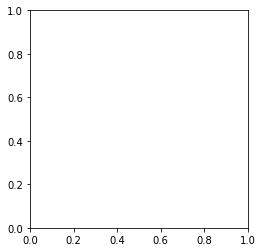

In [7]:
plt.imshow(results_frame[results_frame['Type']=='KRIG'].Sd.values[0])

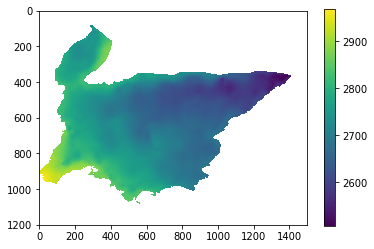

In [22]:
plt.imshow(results_frame[results_frame['Type']=='MPS2'].Mean.values[0])
plt.ylim(1200,0)
plt.xlim(0,1500)
plt.colorbar()

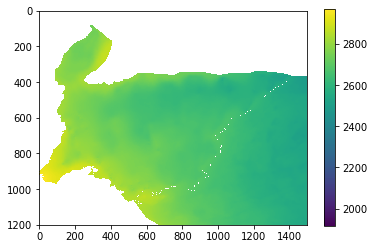

In [25]:
plt.imshow(results_frame[results_frame['Type']=='MPS1'].Mean.values[0])
plt.ylim(1200,0)
plt.xlim(0,1500)
plt.colorbar()

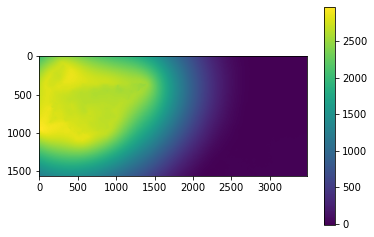

In [28]:
plt.imshow(results_frame[results_frame['Type']=='GRF'].Mean.values[0])
#plt.ylim(1200,0)
#plt.xlim(0,1500)
plt.colorbar()

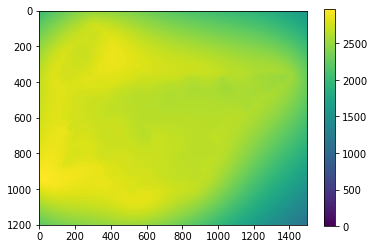

In [27]:
plt.imshow(results_frame[results_frame['Type']=='KRIG'].Mean.values[0])
plt.ylim(1200,0)
plt.xlim(0,1500)
plt.colorbar()

In [25]:
vol_MPS1 = []
vol_MPS2 = []
vol_KRIG = []
vol_GRF = []


for i in range(int(results_frame.shape[0]/4)):
    vol_MPS1.extend(results_frame[results_frame['Type']=='MPS1'].Volume.values[i][:])
    vol_MPS2.extend(results_frame[results_frame['Type']=='MPS2'].Volume.values[i])
    vol_KRIG.extend(results_frame[results_frame['Type']=='KRIG'].Volume.values[i])
    vol_GRF.extend(results_frame[results_frame['Type']=='GRF'].Volume.values[i])

    


Text(0.5, 0, 'Volume [m^2]')

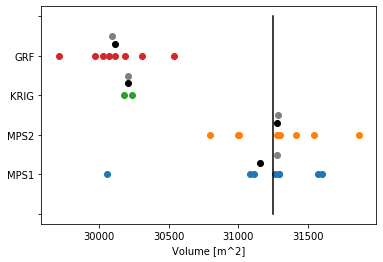

In [28]:
plt.scatter(vol_MPS1,np.ones(len(vol_MPS1)))
plt.scatter(vol_MPS2,np.ones(len(vol_MPS2))+1)
plt.scatter(vol_KRIG,np.ones(len(vol_KRIG))+2)
plt.scatter(vol_GRF,np.ones(len(vol_GRF))+3)
plt.plot([real_vol, real_vol],[0,5],color = 'black')

plt.scatter(np.mean(vol_MPS1),1.3,color = 'black')
plt.scatter(np.mean(vol_MPS2),2.3,color = 'black')
plt.scatter(np.mean(vol_KRIG),3.3,color = 'black')
plt.scatter(np.mean(vol_GRF),4.3,color = 'black')

#plt.text(np.mean(vol_MPS1)+30000,1.3,'Mean')
#plt.text(np.mean(vol_MPS2)+30000,2.3,'Mean')
#plt.text(np.mean(vol_KRIG)+30000,3.3,'Mean')
#plt.text(np.mean(vol_GRF)+30000,4.3,'Mean')

plt.scatter(np.median(vol_MPS1),1.5,color = 'grey')
plt.scatter(np.median(vol_MPS2),2.5,color = 'grey')
plt.scatter(np.median(vol_KRIG),3.5,color = 'grey')
plt.scatter(np.median(vol_GRF),4.5,color = 'grey')

#plt.text(np.median(vol_MPS1)+30000,1.5,'Median')
#plt.text(np.median(vol_MPS2)+30000,2.5,'Median')
#plt.text(np.median(vol_KRIG)+30000,3.5,'Median')
#plt.text(np.median(vol_GRF)+30000,4.5,'Median')

ax = plt.gca()

labels = [item.get_text() for item in ax.get_yticklabels()]
labels[1] = 'Testing'
ax.set_yticklabels(['','','MPS1','MPS2','KRIG','GRF'])



plt.xlabel('Volume [m^3]')